# Crop Yield Prediction in Pakistan

This project analyzes historical agricultural data from Pakistan to predict crop yield (kg/ha).
It demonstrates a complete data science workflow including:

- Data cleaning and preprocessing  
- Exploratory Data Analysis (EDA)  
- Feature engineering and encoding  
- Multiple machine learning models  
- Model evaluation and comparison  
- Feature importance using SHAP  
- Actual vs Predicted Yield (Model Performance)
- Interactive crop yield prediction  

The goal is to showcase a production-ready, explainable, and socially relevant machine learning project.


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

import warnings
warnings.filterwarnings("ignore")


## 1. Load Dataset

We use historical crop yield data that includes information about crops, regions, years, and yield values.
Only officially reported yield data is used for modeling.


In [42]:
df = pd.read_csv("../data/crop_yield_dataset.csv")
df.columns = df.columns.str.strip()

df.head()


,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,586,Pakistan,5412,Yield,112.0,Maize (corn),1961,1961,kg/ha,1030.9,A,Official figure,NaN
1,QCL,Crops and livestock products,586,Pakistan,5510,Production,112.0,Maize (corn),1961,1961,t,487680.0,A,Official figure,NaN
2,QCL,Crops and livestock products,586,Pakistan,5412,Yield,112.0,Maize (corn),1962,1962,kg/ha,1052.5,A,Official figure,NaN
3,QCL,Crops and livestock products,586,Pakistan,5510,Production,112.0,Maize (corn),1962,1962,t,482600.0,A,Official figure,NaN
4,QCL,Crops and livestock products,586,Pakistan,5412,Yield,112.0,Maize (corn),1963,1963,kg/ha,1052.2,A,Official figure,NaN


In [43]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Domain Code       1115 non-null   object 
 1   Domain            1115 non-null   object 
 2   Area Code (M49)   1115 non-null   int64  
 3   Area              1115 non-null   object 
 4   Element Code      1115 non-null   int64  
 5   Element           1115 non-null   object 
 6   Item Code (CPC)   1115 non-null   float64
 7   Item              1115 non-null   object 
 8   Year Code         1115 non-null   int64  
 9   Year              1115 non-null   int64  
 10  Unit              1115 non-null   object 
 11  Value             1115 non-null   float64
 12  Flag              1115 non-null   object 
 13  Flag Description  1115 non-null   object 
 14  Note              0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 130.8+ KB


## 2. Data Cleaning

- Filter the dataset to include only **Yield** records  
- Remove rows with missing target values  
- Fill remaining missing values safely  


In [44]:
df = df[df['Element'] == 'Yield']

df.dropna(subset=['Value'], inplace=True)
df.fillna(0, inplace=True)

df.shape


(548, 15)

## 3. Feature Engineering

Categorical features are converted into numerical format using one-hot encoding.
This allows machine learning models to process non-numeric information such as crop type and region.


In [45]:
categorical_cols = [
    'Domain Code','Domain','Area Code (M49)','Area',
    'Element Code','Element','Item Code (CPC)','Item'
]

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


## 4. Feature Selection

- **Target variable:** Crop Yield (kg/ha)  
- Remove non-predictive identifiers and metadata columns  


In [46]:
y = df_encoded['Value']

X = df_encoded.drop(
    ['Value','Year','Year Code','Unit','Flag','Flag Description','Note'],
    axis=1,
    errors='ignore'
)

X.shape, y.shape


((548, 16), (548,))

## 5. Train-Test Split and Feature Scaling

The dataset is split into training and testing sets.
Standardization is applied to ensure fair model training.


In [47]:
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_columns = X_train_df.columns

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_df)
X_test = scaler.transform(X_test_df)


## 6. Model Training and Comparison

Three models are trained and evaluated:

- Random Forest Regressor  
- Gradient Boosting Regressor  
- Linear Regression  

Performance is measured using R² score and Mean Absolute Error.


In [48]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("Random Forest R²:", round(r2_score(y_test, rf_pred),2))
print("Gradient Boosting R²:", round(r2_score(y_test, gb_pred),2))
print("Linear Regression R²:", round(r2_score(y_test, lr_pred),2))


Random Forest R²: 0.85
Gradient Boosting R²: 0.85
Linear Regression R²: 0.85


### 📊 Actual vs Predicted Yield (Model Performance)

This plot compares actual crop yield values with predictions made by the Random Forest model.
A perfect model would align all points along the diagonal line.


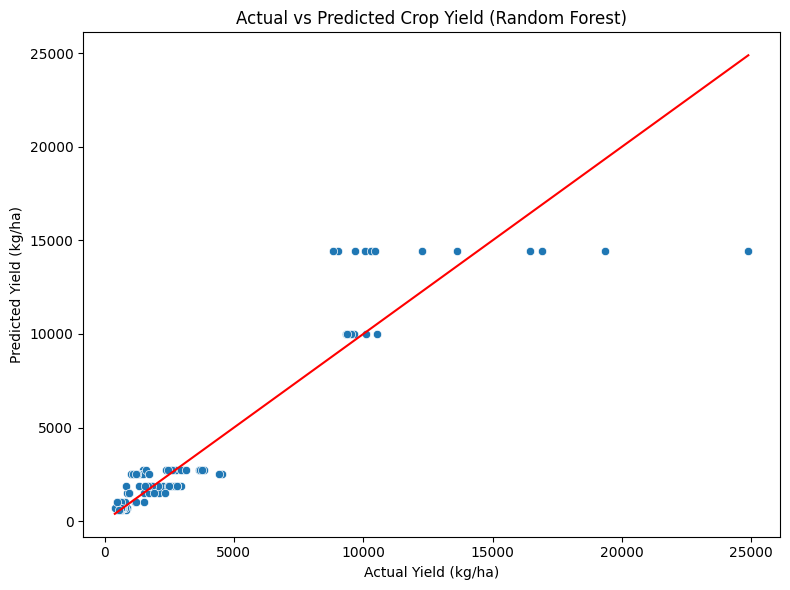

In [49]:
# Actual vs Predicted Scatter Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=rf_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)
plt.xlabel("Actual Yield (kg/ha)")
plt.ylabel("Predicted Yield (kg/ha)")
plt.title("Actual vs Predicted Crop Yield (Random Forest)")
plt.tight_layout()
plt.savefig("../images/actual_vs_predicted.png")
plt.show()


## 7. Feature Importance (SHAP)

SHAP values help explain how different features influence model predictions.
This improves transparency and trust in the model.


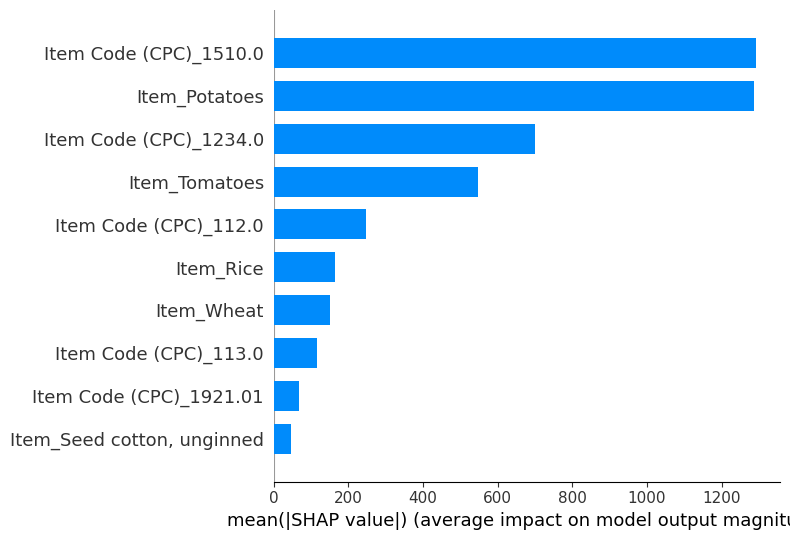

<Figure size 640x480 with 0 Axes>

In [ ]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(
    shap_values,
    X_train_df,
    max_display=10,
    plot_type="bar"
)



## 8. Exploratory Data Analysis

We visualize:
- Crop yield trends over time  
- Correlations between numerical features  


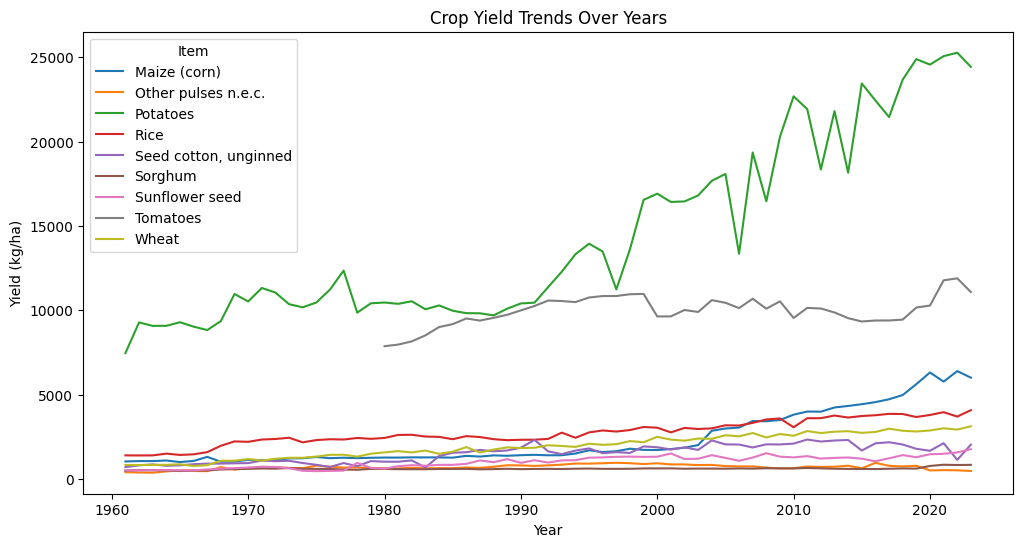

In [56]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='Year', y='Value', hue='Item')
plt.title("Crop Yield Trends Over Years")
plt.xlabel("Year")
plt.ylabel("Yield (kg/ha)")
plt.savefig("../images/crop_yield_trends_over_years.png")

plt.show()


### 🌍 Regional Average Crop Yield

This visualization compares the average crop yield across different regions (areas),
highlighting geographical differences in agricultural productivity.


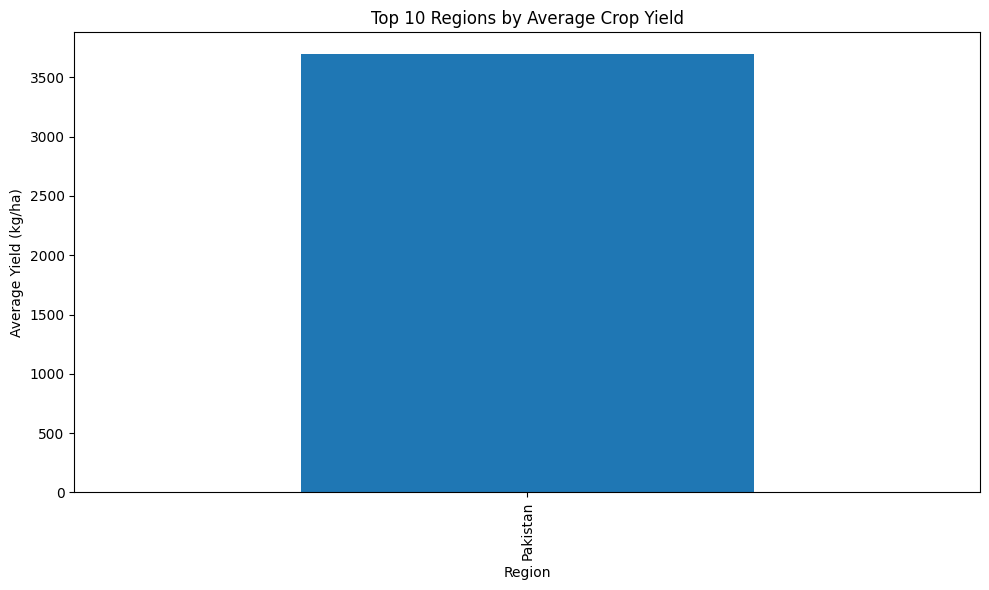

In [57]:
# Regional Average Yield
regional_yield = (
    df.groupby('Area')['Value']
    .mean()
    .sort_values(ascending=False)
    .head(10)  # top 10 regions
)

plt.figure(figsize=(10,6))
regional_yield.plot(kind='bar')
plt.ylabel("Average Yield (kg/ha)")
plt.xlabel("Region")
plt.title("Top 10 Regions by Average Crop Yield")
plt.tight_layout()
plt.savefig("../images/regional_yield.png")
plt.show()


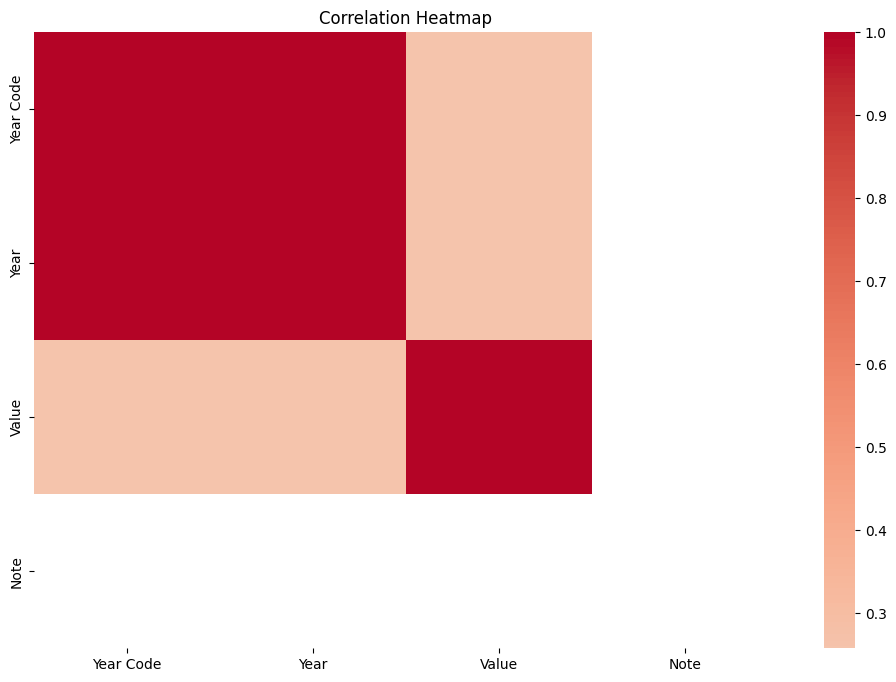

In [58]:
plt.figure(figsize=(12,8))
numeric_df = df_encoded.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.savefig("../images/correlation_heatmap.png")
plt.show()


## 9. Interactive Crop Yield Prediction

Users can input a crop name and year to estimate crop yield using the trained Random Forest model.


In [59]:
crop_input = input("Enter Crop Name (exact from dataset): ").strip()

sample_encoded = pd.DataFrame(0, index=[0], columns=X_train_columns)

crop_cols = [c for c in sample_encoded.columns if c.startswith("Item_")]

for c in crop_cols:
    if crop_input.lower() in c.lower():
        sample_encoded[c] = 1
        break

sample_scaled = scaler.transform(sample_encoded)
prediction = rf_model.predict(sample_scaled)

print(f"Predicted Yield for {crop_input}: {prediction[0]:.2f} kg/ha")


Predicted Yield for rice: 1885.31 kg/ha


## 10. Key Insights

- Ensemble models outperform linear regression for yield prediction  
- Crop type is a dominant predictor of yield  
- Historical agricultural data can meaningfully support food security planning  
- Explainable ML (SHAP) makes predictions transparent and trustworthy  
